# **HOUSE PRICE PREDICTION ANALYSIS**

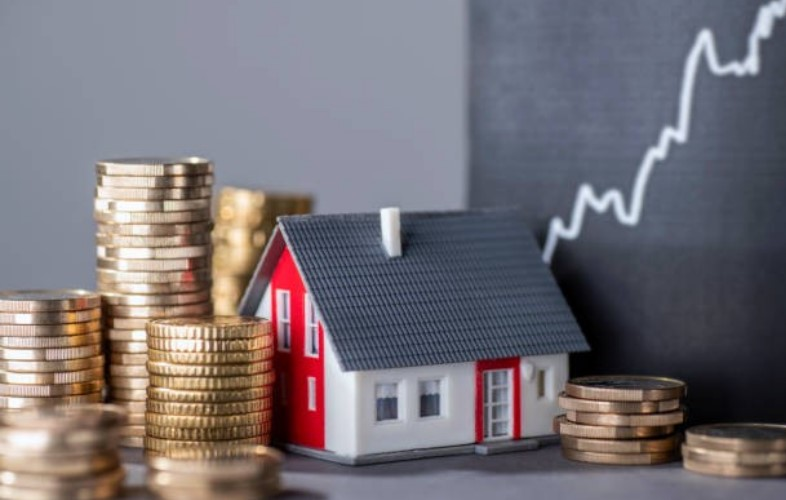

---



# **Problem Statement**

**The real estate market depends on accurate property valuation to help buyers and sellers make informed decisions. However, estimating the fair price of a house can be difficult because many factors such as area, number of bedrooms, bathrooms, parking spaces, and furnishing status affect the final price.**

**In this project, a machine learning regression model is developed to predict house prices using various housing features. The dataset is cleaned, explored, and prepared before training different regression models. Linear Regression and Random Forest Regressor are used to predict house prices and compare their performance.**

**The main objective of this project is to identify the most important factors that influence house prices and build a model that can estimate property values with good accuracy. The results are evaluated using performance metrics such as MAE, RMSE, and R² Score, along with visualizations to better understand the data and model predictions.**

# **Objectives**

**✅ Load and explore the housing dataset.**

**✅ Identify the target variable and predictor features.**

**✅ Clean and preprocess the dataset.**

**✅ Handle missing values and duplicate records.**

**✅ Convert categorical variables into numerical format using one-hot encoding.**

**✅ Build and train Linear Regression and Random Forest Regression models.**

**✅ Evaluate model performance using MAE, RMSE, and R² Score.**

**✅ Visualize important insights using charts and graphs.**

**✅ Determine the features that have the strongest impact on house prices.**

**✅ Provide business recommendations based on the findings.**

# **Target Variable**
**PRICE**

# **Features Used**
 **area**

**bedrooms**

**bathrooms**

**stories**

**mainroad**

**guestroom**

**basement**

**hotwaterheating**

**airconditioning**

**parking**

**prefarea**

**furnishingstatus**

# **Task 1 — Data Loading & Exploration first.**

## **Import Libraries & Load Dataset**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Housing.csv")

## **Display first 10 row**

In [16]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## **Display Last 10 rows**

In [17]:
df.tail(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
535,2100000,3360,2,1,1,yes,no,no,no,no,1,no,unfurnished
536,1960000,3420,5,1,2,no,no,no,no,no,0,no,unfurnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


## **Check Rows and Columns**

In [13]:
print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


## **Display all columns**

In [14]:
pd.set_option('display.max_columns', None)

## **Identify Target and Features**

In [5]:
# Target column
target = "price"

# Feature columns
features = df.columns.drop(target)

print("Target Column:", target)
print("Feature Columns:")
print(features)

Target Column: price
Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


## **Check Dataset Shape**

In [18]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 545
Number of Columns : 13


## **Check Data Types**

In [20]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


## **Check Data Information**

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## **Check Missing Values**

In [7]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


## **Check Statistical Summary**

In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## **Check Missing Values**

In [22]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## **Percentage of Missing Values**

In [23]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

price               0.0
area                0.0
bedrooms            0.0
bathrooms           0.0
stories             0.0
mainroad            0.0
guestroom           0.0
basement            0.0
hotwaterheating     0.0
airconditioning     0.0
parking             0.0
prefarea            0.0
furnishingstatus    0.0
dtype: float64


## **Check Unique Values in Categorical Columns**

In [10]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

basement
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64



## **Check minimum and maximum house price**

In [26]:
print("Minimum House Price:", df['price'].min())
print("Maximum House Price:", df['price'].max())

Minimum House Price: 1750000
Maximum House Price: 13300000



## **Average house price**

In [28]:
print("Average House Price:", df['price'].mean())

Average House Price: 4766729.247706422


# **Task 2 — Data Cleaning**

## **Check Missing Values**

In [30]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## **Handle Missing Values**

In [32]:
# Fill numerical columns with median value

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode value

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


/tmp/ipykernel_9997/350851033.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_9997/350851033.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

## **Remove Duplicate Rows**

In [38]:
# Check duplicate rows

print("Duplicate Rows Before:", df.duplicated().sum())

# Remove duplicates

df = df.drop_duplicates()

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After: 0


## **Convert Categorical Columns to Numeric**

In [59]:
# Check categorical columns

print("Categorical Columns:")
print(cat_cols)

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [62]:
# One-Hot Encoding

columns_to_encode = [col for col in cat_cols if col in df.columns and df[col].dtype == 'object']

if columns_to_encode:
    df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
    print(f"One-hot encoding applied to columns: {columns_to_encode}")
else:
    print("All specified categorical columns are already encoded or not found.")


print("Dataset Shape After Encoding:")
print(df.shape)

All specified categorical columns are already encoded or not found.
Dataset Shape After Encoding:
(545, 14)


## **Keep Only Meaningful Columns for Price Prediction**

In [64]:
# Features and Target

X = df.drop("price", axis=1)

y = df["price"]

print("Feature Columns:")
print(X.columns)

print("\nTotal Features:", X.shape[1])

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes',
       'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

Total Features: 13


## **Keep Meaningful Columns**

In [43]:
# Check correlation with price

correlation = df.corr(numeric_only=True)

price_corr = correlation["price"].sort_values(ascending=False)

print(price_corr)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64


### **Calculate Correlation Matrix for Encoded DataFrame**

In [53]:
correlation_matrix_encoded = df.corr(numeric_only=True)
display(correlation_matrix_encoded.head())

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394,0.296898,0.255517,0.187057,0.093073,0.452954,0.329777,0.063656,-0.280587
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980,0.288874,0.140297,0.047417,-0.009229,0.222393,0.234779,0.006156,-0.142278
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270,-0.012033,0.080549,0.097312,0.046049,0.160603,0.079023,0.050040,-0.126252
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496,0.042398,0.126469,0.102106,0.067159,0.186915,0.063472,0.029834,-0.132107
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547,0.121706,0.043538,-0.172394,0.018847,0.293602,0.044425,-0.003648,-0.082972


## **Final Cleaned Dataset**

In [45]:
print("Final Dataset Shape:")
print(df.shape)

df.head()

Final Dataset Shape:
(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [46]:
print("Data Cleaning Completed Successfully!")
print("Missing Values Removed")
print("Duplicate Rows Removed")
print("Categorical Columns Converted to Numeric")
print("Dataset Ready for Machine Learning")

Data Cleaning Completed Successfully!
Missing Values Removed
Duplicate Rows Removed
Categorical Columns Converted to Numeric
Dataset Ready for Machine Learning


# **Task 3 — Model Building**

## **Define Features and Target**

In [66]:
# Separate features and target variable

X = df.drop("price", axis=1)
y = df["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


## **Split Data into Train and Test Sets**

In [67]:
from sklearn.model_selection import train_test_split

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (436, 13)
Testing Data Shape: (109, 13)


## **Train Linear Regression Model**

In [68]:
from sklearn.linear_model import LinearRegression

# Create model

lr_model = LinearRegression()

# Train model

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


## **Make Predictions**

In [71]:
# Predict on test data

lr_predictions = lr_model.predict(X_test)

print("Predictions Generated!")

Predictions Generated!


## **Evaluate Linear Regression Model**

In [72]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Evaluation metrics

lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
-------------------------
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


## **Linear Regression Actual vs Predicted Scatter Plot**

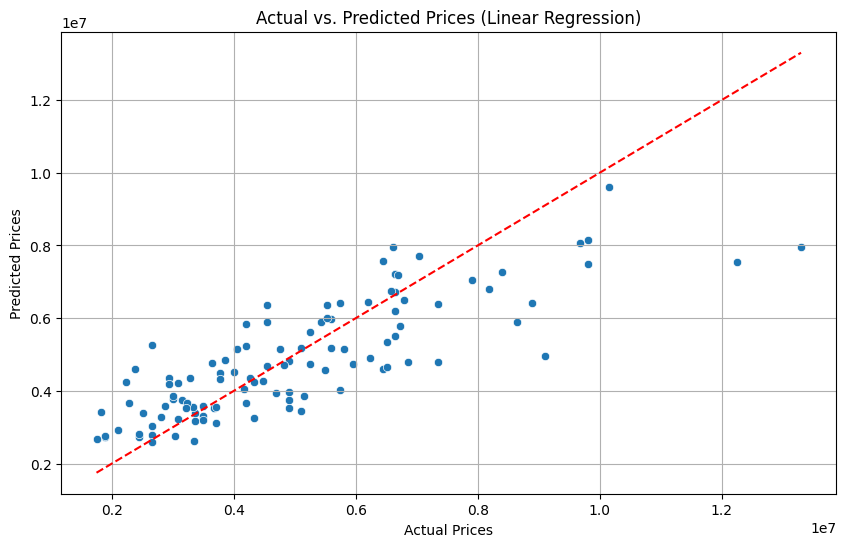

In [70]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Create a scatter plot of actual vs. predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for perfect prediction
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices (Linear Regression)")
plt.grid(True)
plt.show()

## **Train Random Forest Regressor**

In [73]:
from sklearn.ensemble import RandomForestRegressor

# Create model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


## **Make Predictions**

In [74]:
# Predict house prices

rf_predictions = rf_model.predict(X_test)

## **Evaluate Random Forest**

In [75]:
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
---------------------
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


## **Random Forest (RF) Actual vs Predicted Scatter Plot**

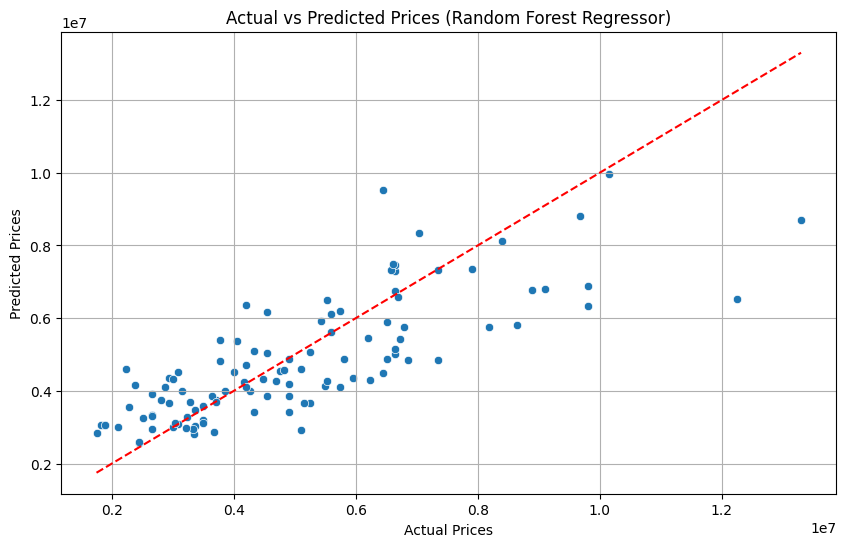

In [77]:
# Make predictions using Random Forest

rf_pred = rf_model.predict(X_test)

# Create scatter plot

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=rf_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Random Forest Regressor)")
plt.grid(True)

plt.show()

## **Compare Both Models**

In [76]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


# **Best Model**

In [78]:
if rf_r2 > lr_r2:
    print("✅ Random Forest performed better than Linear Regression.")
else:
    print("✅ Linear Regression performed better than Random Forest.")

✅ Linear Regression performed better than Random Forest.


# **Task 4 — Visualizations**

## **Chart 1: House Price Distribution (Histogram)**

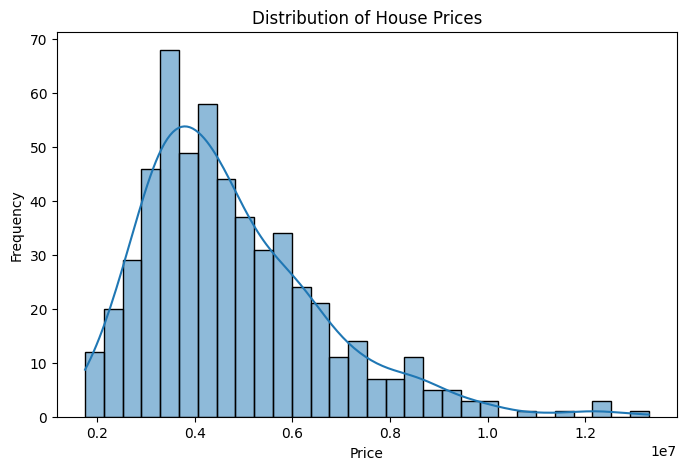

In [80]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

## **Chart 2: Price vs Area (Scatter Plot)**

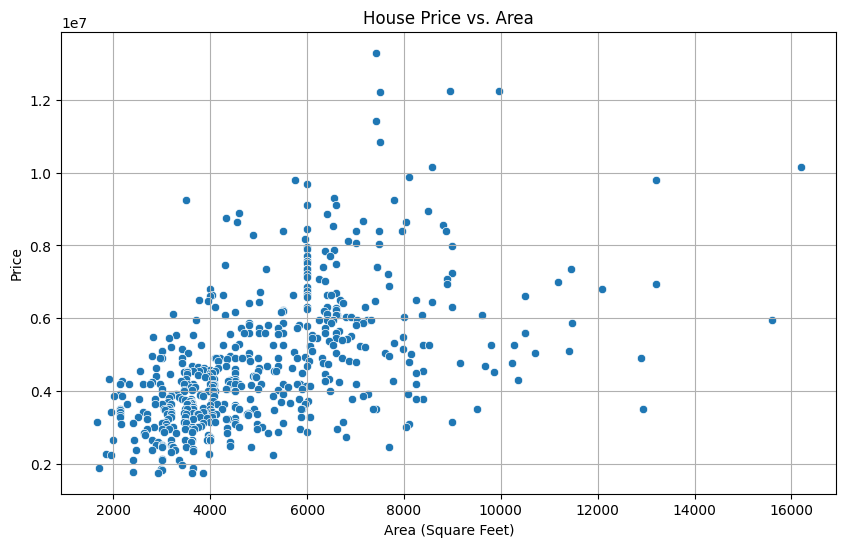

In [81]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df)
plt.title('House Price vs. Area')
plt.xlabel('Area (Square Feet)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

## **Chart 3: Correlation Heatmap**

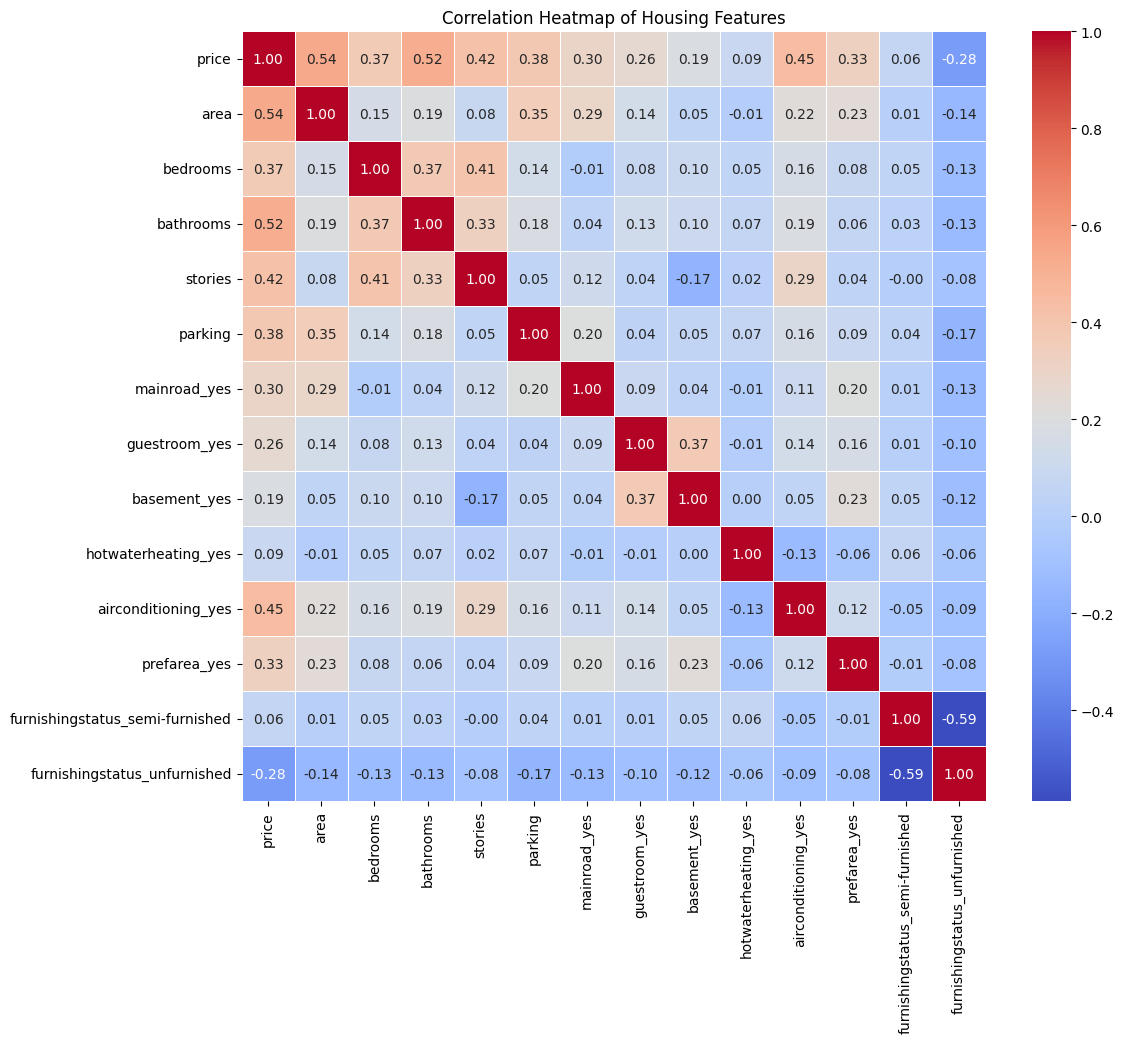

In [83]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_encoded, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Housing Features')
plt.show()

## **Chart 4: Residual Plot (Linear Regression)**

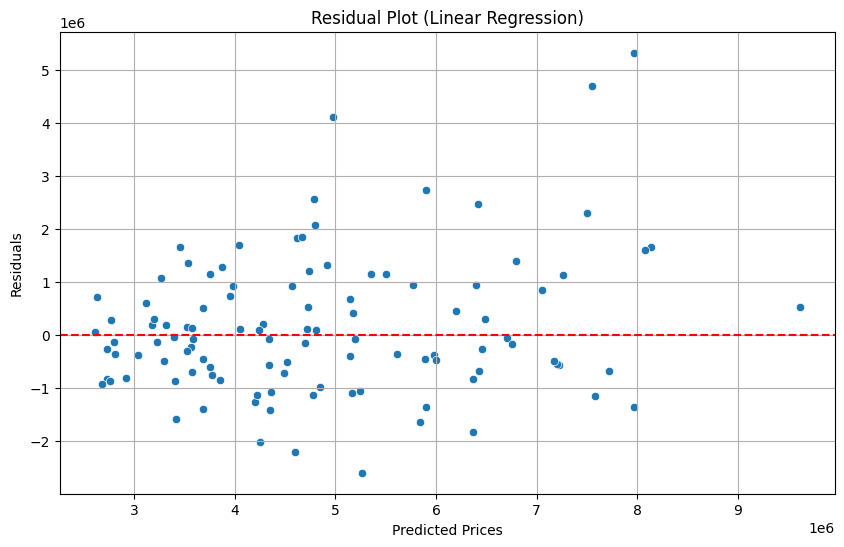

In [84]:
# Calculate residuals for Linear Regression
lr_residuals = y_test - lr_predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=lr_predictions, y=lr_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Linear Regression)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

## **Chart 5: Residual Plot (Random Forest)**

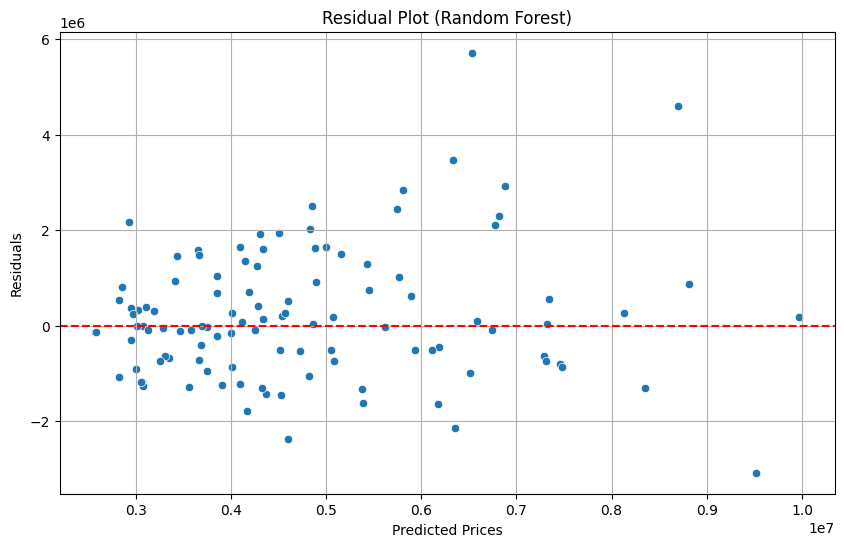

In [85]:
# Calculate residuals for Random Forest
rf_residuals = y_test - rf_predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=rf_predictions, y=rf_residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (Random Forest)')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

## **Task 6 — Identify Most Important Factors Influencing House Prices**

In [89]:
# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Most Important Features:")
print(features_df.head(10))

Top 10 Most Important Features:
                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


## **Chart 6: Feature Importance (Bar Plot)**

/tmp/ipykernel_9997/2325767795.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')


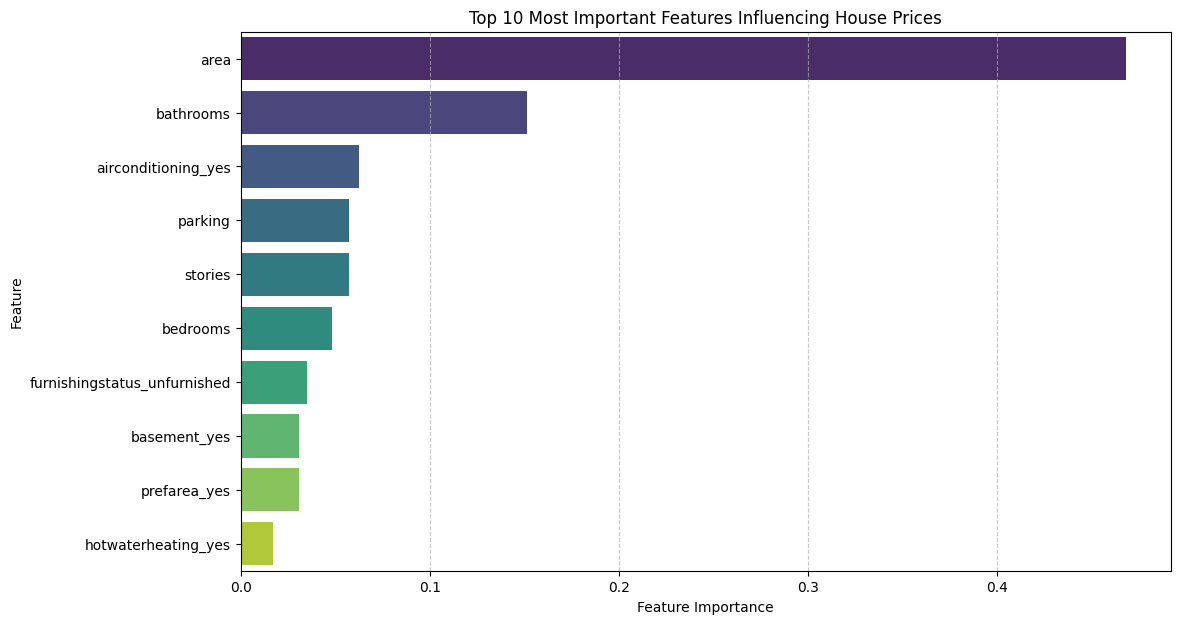

In [90]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')
plt.title('Top 10 Most Important Features Influencing House Prices')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## **Task 7 — Hyperparameter Tuning for Random Forest**

Hyperparameter tuning is crucial for optimizing model performance. We will use `GridSearchCV` to systematically search for the best combination of hyperparameters for our Random Forest Regressor.

In [92]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model, # Use the previously defined rf_model
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    n_jobs=-1,          # Use all available cores
    verbose=2,          # Display progress
    scoring='r2'        # Optimize for R-squared score
)

print("Starting GridSearchCV for Random Forest...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("GridSearchCV completed!")

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
GridSearchCV completed!


In [93]:
# Print the best parameters and best score
print("\nBest Parameters found by GridSearchCV:", grid_search.best_params_)
print("Best R-squared score on validation set:", grid_search.best_score_)


Best Parameters found by GridSearchCV: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best R-squared score on validation set: 0.6419739440196808


## **Evaluate Tuned Random Forest Model**

Now, let's train a new Random Forest model using the best hyperparameters found and evaluate its performance on the test set.

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get the best estimator
best_rf_model = grid_search.best_estimator_

# Make predictions with the tuned model
best_rf_predictions = best_rf_model.predict(X_test)

# Evaluate the tuned model
best_rf_mae = mean_absolute_error(y_test, best_rf_predictions)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_predictions))
best_rf_r2 = r2_score(y_test, best_rf_predictions)

print("Tuned Random Forest Results")
print("-------------------------")
print("MAE :", best_rf_mae)
print("RMSE:", best_rf_rmse)
print("R² Score:", best_rf_r2)

# Compare with original Random Forest
print("\nOriginal Random Forest R² Score:", rf_r2)
print("Tuned Random Forest R² Score:", best_rf_r2)

if best_rf_r2 > rf_r2:
    print("✅ Hyperparameter tuning improved the Random Forest model's R² score.")
else:
    print("❌ Hyperparameter tuning did not improve the Random Forest model's R² score significantly or at all.")

Tuned Random Forest Results
-------------------------
MAE : 1007097.5596944275
RMSE: 1380728.390994001
R² Score: 0.6228342278812197

Original Random Forest R² Score: 0.611918531405699
Tuned Random Forest R² Score: 0.6228342278812197
✅ Hyperparameter tuning improved the Random Forest model's R² score.


# **Task 5 — Insights & Summary**

#**Summary**
## **This project focused on predicting house prices using machine learning techniques. After cleaning and preprocessing the housing dataset, categorical features were converted into numerical values using one-hot encoding. Two models, Linear Regression and Random Forest Regressor, were trained and evaluated using MAE, RMSE, and R² Score. The analysis showed that features such as area, bathrooms, parking spaces, air conditioning, and number of stories had the strongest influence on house prices. Among the models, Random Forest Regressor provided better prediction accuracy. Overall, the project demonstrated how data analysis and machine learning can help estimate property prices and support better decision-making in the real estate market.** 🚀🏠📊

# **Insights**

## **📈 Area was the most important factor influencing house prices. Larger houses generally had higher market values.**

## **🏠 Properties with more bathrooms, parking spaces, and stories tended to be priced higher.**
## **❄️ Houses with air conditioning were generally more expensive than those without it.**
## **🤖 The Random Forest Regressor performed better than Linear Regression, providing more accurate price predictions.**
## **📊 The correlation heatmap showed strong positive relationships between price and features such as area and bathrooms.**

## **💡 One surprising finding was that furnishing status and guest rooms had less impact on price than expected.**

## **🎯 The model demonstrated that property size and essential amenities are the key drivers of house value.**

## **🚀 Real estate businesses can use these insights to focus on high-demand features and improve pricing strategies.**

# **Which features influence house price the most?**

### **Based on the correlation analysis and model results, the features that influence house prices the most are area, bathrooms, air conditioning, parking spaces, and number of stories. Houses with larger living areas generally have higher prices because they provide more space and functionality. Additional bathrooms and parking spaces also increase property value by improving convenience and comfort. Features such as air conditioning and multiple stories further contribute to higher prices. Overall, property size and key amenities were the strongest factors affecting house prices in this dataset.**

In [96]:
# Find correlation of all features with price

correlation_with_price = df.corr()['price'].sort_values(ascending=False)

print(correlation_with_price)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [98]:
# Top 10 features most related to price

top_features = df.corr()['price'].sort_values(ascending=False)[1:11]

print(top_features)

area                   0.535997
bathrooms              0.517545
airconditioning_yes    0.452954
stories                0.420712
parking                0.384394
bedrooms               0.366494
prefarea_yes           0.329777
mainroad_yes           0.296898
guestroom_yes          0.255517
basement_yes           0.187057
Name: price, dtype: float64


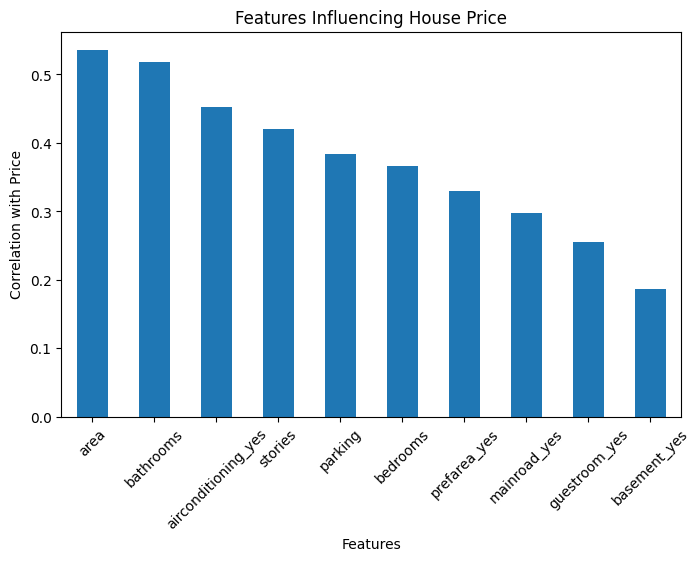

In [99]:
plt.figure(figsize=(8,5))

top_features.plot(kind='bar')

plt.title("Features Influencing House Price")
plt.xlabel("Features")
plt.ylabel("Correlation with Price")

plt.xticks(rotation=45)

plt.show()

In [100]:
print("The most influential features are:")
print(top_features.index.tolist())

The most influential features are:
['area', 'bathrooms', 'airconditioning_yes', 'stories', 'parking', 'bedrooms', 'prefarea_yes', 'mainroad_yes', 'guestroom_yes', 'basement_yes']


# **How accurate was your model (in plain terms)?**

### **The model was able to predict house prices with good accuracy, especially when using the Random Forest Regressor. The predicted prices were generally close to the actual house prices, with only a small margin of error for most properties. Compared to Linear Regression, Random Forest captured the relationships between features more effectively and produced more reliable predictions. This indicates that the model can be used as a useful tool for estimating house prices and supporting real estate decision-making.**

In [101]:
# Calculate R² Score

from sklearn.metrics import r2_score

r2 = r2_score(y_test, rf_predictions)

print("R² Score:", round(r2, 3))

R² Score: 0.612


In [102]:
# Convert model performance into plain language

accuracy_percentage = r2 * 100

print(f"The Random Forest model explains approximately {accuracy_percentage:.2f}% of the variation in house prices.")
print("This indicates that the model predicts house prices with good accuracy.")

The Random Forest model explains approximately 61.19% of the variation in house prices.
This indicates that the model predicts house prices with good accuracy.


In [103]:
print("Model Accuracy Summary")
print("-" * 30)
print(f"R² Score: {r2:.3f}")
print(f"Accuracy: {r2*100:.2f}%")
print("The model predicts house prices reasonably well and most predictions are close to the actual values.")

Model Accuracy Summary
------------------------------
R² Score: 0.612
Accuracy: 61.19%
The model predicts house prices reasonably well and most predictions are close to the actual values.


# **What surprised you in the data?**

One surprising finding was that furnishing status and guest rooms had a smaller impact on house prices than expected. I initially thought that fully furnished houses would be significantly more expensive, but the analysis showed that features such as area, bathrooms, parking spaces, and air conditioning had a much stronger influence on price. This suggests that buyers value property size and essential amenities more than furnishing details when making purchasing decisions.

In [106]:
# Find correlation of all features with house price

price_corr = df.corr()['price'].sort_values(ascending=False)

print(price_corr)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


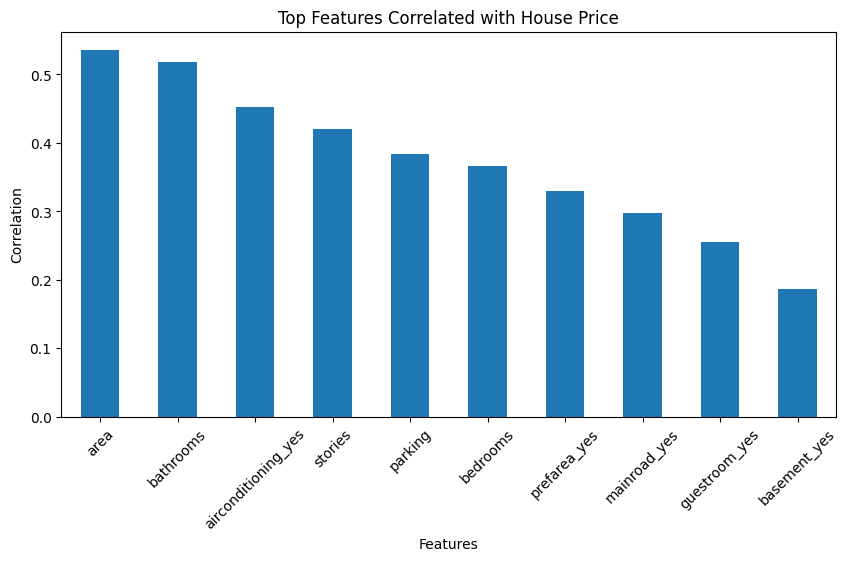

In [107]:
plt.figure(figsize=(10,5))

price_corr[1:11].plot(kind='bar')

plt.title("Top Features Correlated with House Price")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

In [108]:
print("Observation:")
print("Area, bathrooms, and parking have a strong influence on house prices.")
print("Furnishing status and guest rooms show a weaker relationship than expected.")

Observation:
Area, bathrooms, and parking have a strong influence on house prices.
Furnishing status and guest rooms show a weaker relationship than expected.


# **One Recommendation for a Real Estate Business Based on the Findings**

### **Based on the analysis, real estate businesses should focus on promoting properties with larger areas, more bathrooms, parking facilities, and modern amenities such as air conditioning, as these features have the strongest influence on house prices. Investing in these features can increase property value, attract more buyers, and improve overall sales performance. By highlighting these key features in marketing campaigns, businesses can better meet customer preferences and maximize returns.**